# Configuration

In [1]:
import os 
import pickle 

if True ^ os.getcwd().endswith("winners-curse"):
    os.chdir('..')

from typing import Iterable, Union
from joblib import Parallel, delayed

In [2]:
import random
import pandas as pd 
import numpy as np

from tqdm import tqdm

In [3]:
from scipy.stats import ttest_ind, norm
from scipy.integrate import quad 

In [4]:
# visualization
import matplotlib.pyplot as plt
import seaborn as sns

# visualization params
# label size
tick_label_size = 12
legend_label_size = 12
axis_label_size = 14
title_size = 18
# font
plt.rcParams['font.family'] = 'serif'

# model label map 
model_label_map = {
    'plugin': 'Plugin', 
    'standard_bootstrap': 'Standard Bootstrap', 
    'mn_bootstrap': 'm-out-of-n Bootstrap', 
    'num_bootstrap': 'Numerical Bootstrap'
}

In [5]:
from core.dgp import RCTs
import core.rct as rct
from core.variables import UnivariateGaussian

# DGP

In [6]:
dgp = RCTs(n_experiments=100, prior_mean=0.1, prior_std=0.1, noise_std=1.0, prior_seed=0)

In [7]:
treated_sample, control_sample = dgp.sample(sample_size=5000, seed=0)

# Estimation

In [9]:
emp_te_arr, _, p_val_arr = rct.difference_in_means(treated_sample, control_sample)

# Selection

In [11]:
significant_selection = rct.select_significant_experiments(treatment_effects=emp_te_arr, p_vals=p_val_arr, alpha=0.05)
threshold_selection = rct.select_above_threshold(treatment_effects=emp_te_arr, p_vals=p_val_arr, threshold=0.0)
largest_selection = rct.select_largest_effects(treatment_effects=emp_te_arr, p_vals=p_val_arr, k=0.1)
bh_selection = rct.select_bh(treatment_effects=emp_te_arr, p_vals=p_val_arr, fdr=0.05)

# Evaluation

In [13]:
significant_val_est = rct.obj_func(significant_selection, emp_te_arr)
significant_val_true = rct.obj_func(significant_selection, dgp.treatment_effects)
significant_wc = significant_val_est - significant_val_true

threshold_val_est = rct.obj_func(threshold_selection, emp_te_arr)
threshold_val_true = rct.obj_func(threshold_selection, dgp.treatment_effects)
threshold_wc = threshold_val_est - threshold_val_true

largest_val_est = rct.obj_func(largest_selection, emp_te_arr)
largest_val_true = rct.obj_func(largest_selection, dgp.treatment_effects)
largest_wc = largest_val_est - largest_val_true

bh_val_est = rct.obj_func(bh_selection, emp_te_arr)
bh_val_true = rct.obj_func(bh_selection, dgp.treatment_effects)
bh_wc = bh_val_est - bh_val_true

result_df = pd.DataFrame({
    'Significant': [significant_val_est, significant_val_true, significant_wc],
    'Threshold': [threshold_val_est, threshold_val_true, threshold_wc],
    'Largest': [largest_val_est, largest_val_true, largest_wc],
    'BH': [bh_val_est, bh_val_true, bh_wc], 
}, index=['Estimated Policy Value', 'True Policy Value', 'Winner\'s Curse'])
result_df

,Significant,Threshold,Largest,BH
Estimated Policy Value,11.466530,11.690513,2.826133,0.312167
True Policy Value,11.077958,11.337929,2.795540,0.324089
Winner's Curse,0.388572,0.352584,0.030592,-0.011923


In [14]:
del dgp, treated_sample, control_sample, emp_te_arr, p_val_arr, significant_selection, threshold_selection, largest_selection, bh_selection
del significant_val_est, significant_val_true, significant_wc, threshold_val_est, threshold_val_true, threshold_wc, largest_val_est, largest_val_true, largest_wc, bh_val_est, bh_val_true, bh_wc

# Winner's Curse

In [15]:
optimization_params = {
    'significant': {
        'optimizer': rct.select_significant_experiments,
        'params': {}, 
        'display_name': 'Significance'
    }, 
    'threshold': {
        'optimizer': rct.select_above_threshold,
        'params': {'threshold': 0.0},
        'display_name': 'Threshold'
    },
    'largest': {
        'optimizer': rct.select_largest_effects,
        'params': {'k': 0.1},
        'display_name': 'Largest'
    },
    'bh': {
        'optimizer': rct.select_bh,
        'params': {'fdr': 0.05},
        'display_name': 'Benjamini-Hochberg'
    }
}

dgp_params = {
    'n_experiments': 100, 
    'prior_mean': 0.1, 
    'prior_std': 0.1,
    'noise_std': 1.0, 
    'prior_seed': 0,
}

data_params = {'sample_size': 100}

experiment_params = {'n_repeats': 1000}

estimators_dict = {}

result_records = rct.repeated_experiment(
    optimization_params=optimization_params, 
    dgp_params=dgp_params, 
    data_params=data_params, 
    experiment_params=experiment_params, 
    estimators_dict=estimators_dict, 
    verbose=True, 
    n_jobs=-1
)

Running 1000 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:    2.5s
[Parallel(n_jobs=-1)]: Done 1000 out of 1000 | elapsed:    2.7s finished


In [16]:
for optimizer in optimization_params.keys():
    display_name = optimization_params[optimizer]['display_name']
    # unpack results
    wc_arr = np.array([result[f'{optimizer}_wc'] for result in result_records])
    val_true_arr = np.array([result[f'{optimizer}_val_true'] for result in result_records])
    val_est_arr = np.array([result[f'{optimizer}_val_est'] for result in result_records])

    wc_avg = wc_arr.mean()
    wc_se = wc_arr.std() / data_params['sample_size'] ** 0.5 

    val_true_avg = val_true_arr.mean()
    val_true_se = val_true_arr.std() / data_params['sample_size'] ** 0.5
    val_est_avg = val_est_arr.mean()
    val_est_se = val_est_arr.std() / data_params['sample_size'] ** 0.5

    print(f'\nSelection with {display_name}:')
    print(f'  - Average True Value: {val_true_avg:.4f} ({val_true_se:.4f})')
    print(f'  - Average Estimated Value: {val_est_avg:.4f} ({val_est_se:.4f})')
    print(f'  - Average Winner\'s Curse: {wc_avg:.4f} ({wc_se:.4f})')


Selection with Significance:
  - Average True Value: 3.1566 (0.0651)
  - Average Estimated Value: 5.9775 (0.1290)
  - Average Winner's Curse: 2.8209 (0.0755)

Selection with Threshold:
  - Average True Value: 9.6578 (0.0404)
  - Average Estimated Value: 13.5111 (0.1128)
  - Average Winner's Curse: 3.8533 (0.1034)

Selection with Largest:
  - Average True Value: 2.0887 (0.0235)
  - Average Estimated Value: 4.0767 (0.0317)
  - Average Winner's Curse: 1.9880 (0.0340)

Selection with Benjamini-Hochberg:
  - Average True Value: 0.2548 (0.0121)
  - Average Estimated Value: 0.5646 (0.0209)
  - Average Winner's Curse: 0.3098 (0.0136)


# Estimating Winner's Curse

In [17]:
dgp = RCTs(**dgp_params)
treated_sample, control_sample = dgp.sample(sample_size=data_params['sample_size'], seed=0)

## Standard Bootstrap

In [18]:
boot_wc_dstn_dict = rct.get_wc_boot_dstn(
    treated_sample=treated_sample, control_sample=control_sample, 
    optimization_params=optimization_params, 
    n_bootstraps=1000, n_jobs=-1, verbose=True, seed=0
)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 1000 out of 1000 | elapsed:    0.2s finished


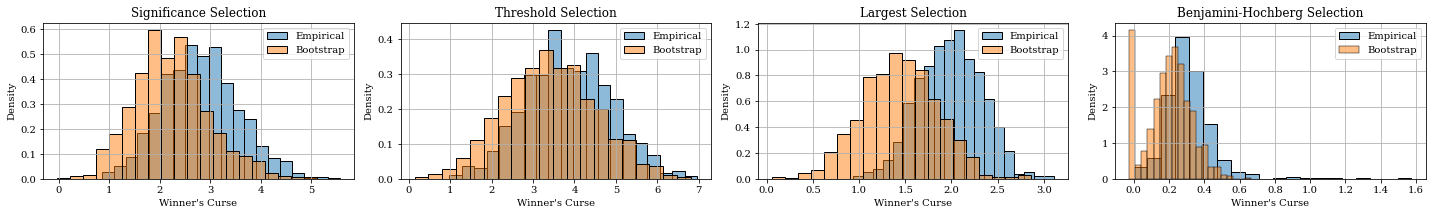

In [19]:
fig, axes = plt.subplots(1, 4, figsize=(20, 3.09))

for i, optimizer_name in enumerate(optimization_params.keys()):
    display_name = optimization_params[optimizer_name]['display_name']
    
    wc_dstn = np.array([result[f'{optimizer_name}_wc'] for result in result_records])
    wc_boot_dstn = boot_wc_dstn_dict[optimizer_name]

    sns.histplot(wc_dstn, bins=20, color='C0', alpha=0.5, stat='density', label='Empirical', ax=axes[i])
    sns.histplot(wc_boot_dstn, bins=20, color='C1', alpha=0.5, stat='density', label='Bootstrap', ax=axes[i])
    axes[i].set_xlabel('Winner\'s Curse')
    axes[i].set_ylabel('Density')
    axes[i].set_title(f'{display_name} Selection')
    axes[i].legend()
    axes[i].grid()

plt.tight_layout()
plt.show()

## m-out-of-n Bootstrap

In [20]:
boot_wc_dstn_dict = rct.get_wc_m_out_of_n_boot_dstn(
    treated_sample=treated_sample, control_sample=control_sample, 
    optimization_params=optimization_params, 
    n_bootstraps=1000, power=0.95, 
    n_jobs=-1, verbose=True, seed=0
)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 1000 out of 1000 | elapsed:    0.2s finished


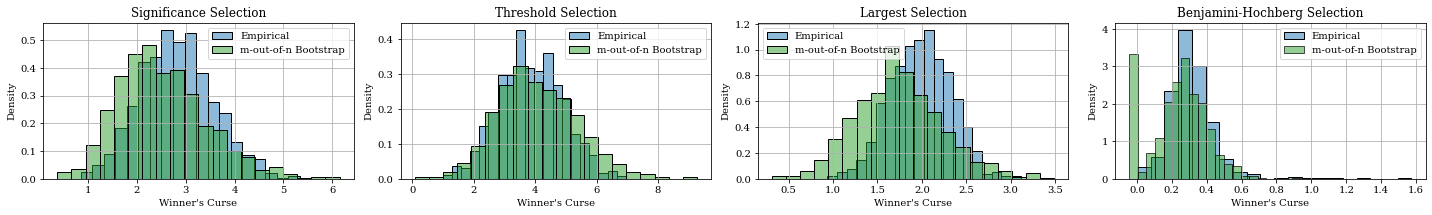

In [21]:
fig, axes = plt.subplots(1, 4, figsize=(20, 3.09))

for i, optimizer_name in enumerate(optimization_params.keys()):
    display_name = optimization_params[optimizer_name]['display_name']
    
    wc_dstn = np.array([result[f'{optimizer_name}_wc'] for result in result_records])
    wc_boot_dstn = boot_wc_dstn_dict[optimizer_name]

    sns.histplot(wc_dstn, bins=20, color='C0', alpha=0.5, stat='density', label='Empirical', ax=axes[i])
    sns.histplot(wc_boot_dstn, bins=20, color='C2', alpha=0.5, stat='density', label='m-out-of-n Bootstrap', ax=axes[i])
    axes[i].set_xlabel('Winner\'s Curse')
    axes[i].set_ylabel('Density')
    axes[i].set_title(f'{display_name} Selection')
    axes[i].legend()
    axes[i].grid()

plt.tight_layout()
plt.show()

## Numerical Bootstrap

In [22]:
boot_wc_dstn_dict = rct.get_wc_num_boot_dstn(
    treated_sample=treated_sample, control_sample=control_sample, 
    optimization_params=optimization_params, 
    n_bootstraps=1000, power=-0.45, 
    n_jobs=-1, verbose=True, seed=0
)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 1000 out of 1000 | elapsed:    0.2s finished


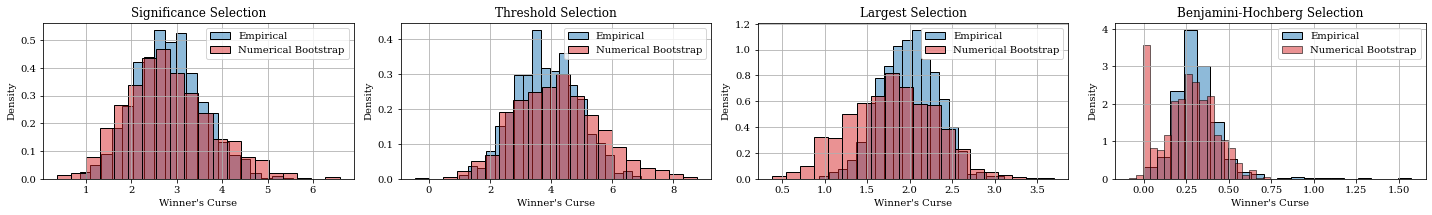

In [23]:
fig, axes = plt.subplots(1, 4, figsize=(20, 3.09))

for i, optimizer_name in enumerate(optimization_params.keys()):
    display_name = optimization_params[optimizer_name]['display_name']
    
    wc_dstn = np.array([result[f'{optimizer_name}_wc'] for result in result_records])
    wc_boot_dstn = boot_wc_dstn_dict[optimizer_name]

    sns.histplot(wc_dstn, bins=20, color='C0', alpha=0.5, stat='density', label='Empirical', ax=axes[i])
    sns.histplot(wc_boot_dstn, bins=20, color='C3', alpha=0.5, stat='density', label='Numerical Bootstrap', ax=axes[i])
    axes[i].set_xlabel('Winner\'s Curse')
    axes[i].set_ylabel('Density')
    axes[i].set_title(f'{display_name} Selection')
    axes[i].legend()
    axes[i].grid()

plt.tight_layout()
plt.show()

In [24]:
del dgp, treated_sample, control_sample, boot_wc_dstn_dict

# Bias Correction

In [13]:
optimization_params = {
    'significant': {
        'optimizer': rct.select_significant_experiments,
        'params': {}, 
        'display_name': 'Significance'
    }, 
    'threshold': {
        'optimizer': rct.select_above_threshold,
        'params': {'threshold': 0.0},
        'display_name': 'Threshold'
    },
    'largest': {
        'optimizer': rct.select_largest_effects,
        'params': {'k': 0.1},
        'display_name': 'Largest'
    },
    'bh': {
        'optimizer': rct.select_bh,
        'params': {'fdr': 0.05},
        'display_name': 'Benjamini-Hochberg'
    }
}

dgp_params = {
    'n_experiments': 100, 
    'prior_mean': 0.1, 
    'prior_std': 0.1, 
    'noise_std': 1.0, 
    'prior_seed': 0,
}

data_params = {'sample_size': 100}

experiment_params = {'n_repeats': 1000}

estimators_dict = {
    'standard_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'bootstrap_method': 'standard', 'n_jobs': 1}, 
        'display_name': 'Standard Bootstrap', 
    }, 
    'm_out_of_n_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'power': 0.95, 'bootstrap_method': 'm_out_of_n', 'n_jobs': 1}, 
        'display_name': 'm-out-of-n Bootstrap', 
    },
    'numerical_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'power': -0.45, 'bootstrap_method': 'numerical', 'n_jobs': 1}, 
        'display_name': 'Numerical Bootstrap', 
    }, 
    'bayes_normal': {
        'estimator': rct.bayes_estimate, 
        'params': {'prior': 'normal', 'prior_mean': 0.0, 'prior_std': 1.0},
        'display_name': 'Bayes (Normal)'
    }, 
    'eb_normal': {
        'estimator': rct.empirical_bayes_estimate,
        'params': {'prior': 'normal', 'dof': 3, 'bin_width': 0.2}, 
        'display_name': 'EB (Normal)'
    }, 
    'eb_spike_slab': {
        'estimator': rct.empirical_bayes_estimate, 
        'params': {'prior': 'spike_slab', 'pi': 0.5},
        'display_name': 'EB (Spike-and-Slab)'
    }
}

In [ ]:
result_records = rct.repeated_experiment(
    optimization_params=optimization_params, 
    dgp_params=dgp_params, 
    data_params=data_params, 
    experiment_params=experiment_params, 
    estimators_dict=estimators_dict,
    verbose=True, 
    n_jobs=-1
)

wc_measures_dict = rct.calculate_winners_curse_measures(
    result_records=result_records, 
    optimization_params=optimization_params, 
    estimators_dict=estimators_dict, 
    data_params=data_params
)

Running 1000 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:    1.8s



Winner's Curse of Selection with Significance:
  - No Correction: 0.3751 (0.0247)
  - Standard Bootstrap: 0.0564 (0.0254)
  - m-out-of-n Bootstrap: 0.0163 (0.0242)
  - Numerical Bootstrap: -0.0263 (0.0257)
  - Bayes (Normal): 0.3550 (0.0239)
  - EB (Normal): 0.3219 (0.0286)
  - EB (Spike-and-Slab): 0.1637 (0.0214)


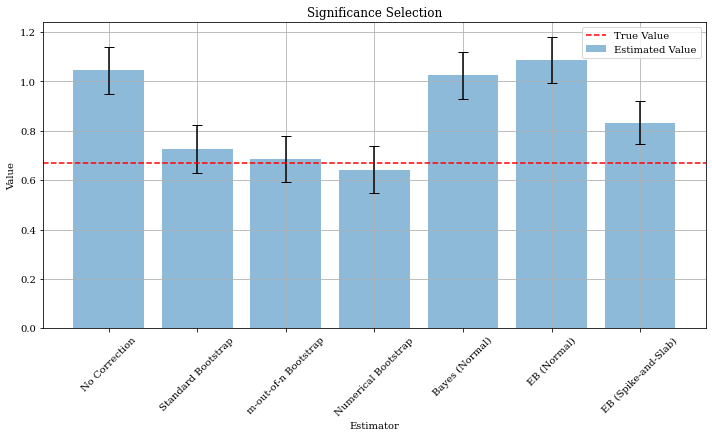


Winner's Curse of Selection with Threshold:
  - No Correction: 0.2660 (0.0359)
  - Standard Bootstrap: 0.0048 (0.0409)
  - m-out-of-n Bootstrap: -0.0574 (0.0415)
  - Numerical Bootstrap: -0.0631 (0.0422)
  - Bayes (Normal): 0.2297 (0.0352)
  - EB (Normal): 0.1740 (0.0459)
  - EB (Spike-and-Slab): 0.0804 (0.0408)


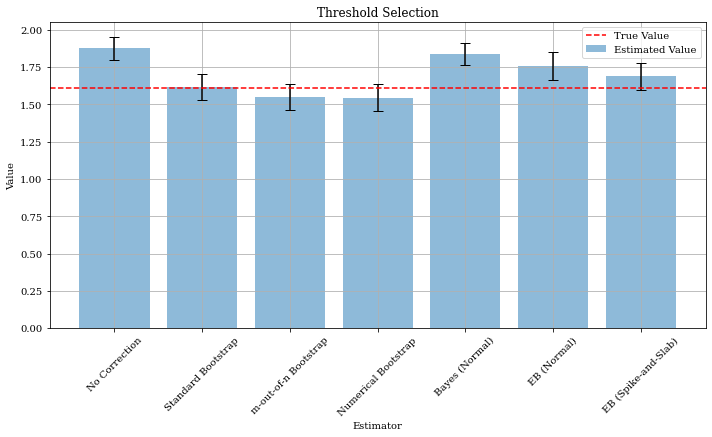


Winner's Curse of Selection with Largest:
  - No Correction: 0.1720 (0.0102)
  - Standard Bootstrap: 0.0348 (0.0126)
  - m-out-of-n Bootstrap: 0.0072 (0.0126)
  - Numerical Bootstrap: -0.0007 (0.0133)
  - Bayes (Normal): 0.1635 (0.0101)
  - EB (Normal): 0.1587 (0.0119)
  - EB (Spike-and-Slab): 0.0639 (0.0100)


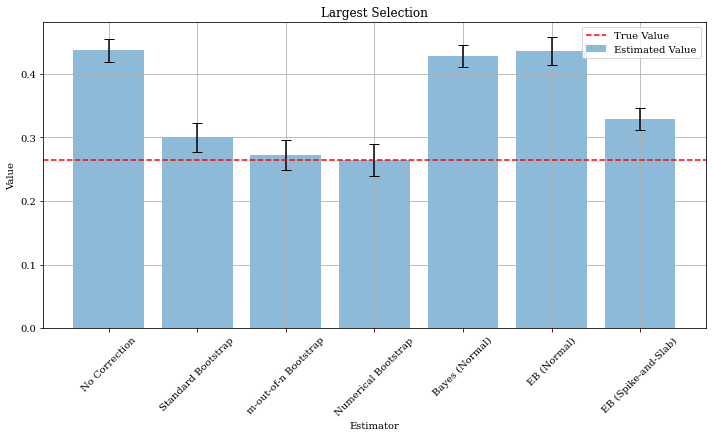


Winner's Curse of Selection with Benjamini-Hochberg:
  - No Correction: 0.1765 (0.0105)
  - Standard Bootstrap: 0.0420 (0.0126)
  - m-out-of-n Bootstrap: 0.0147 (0.0126)
  - Numerical Bootstrap: 0.0071 (0.0132)
  - Bayes (Normal): 0.1679 (0.0104)
  - EB (Normal): 0.1570 (0.0117)
  - EB (Spike-and-Slab): 0.0668 (0.0100)


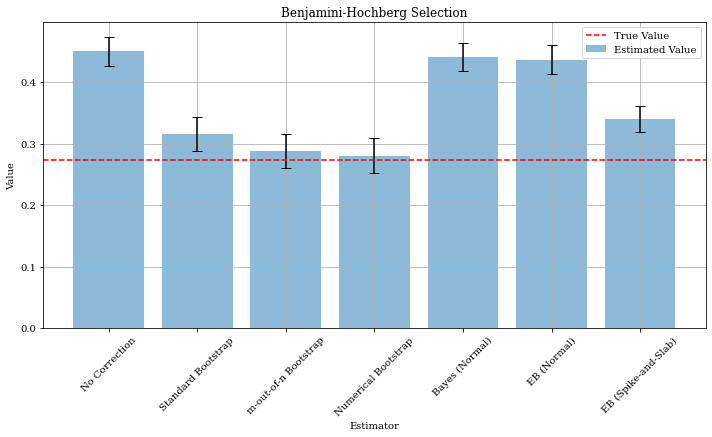

In [ ]:
for optimizer_key in optimization_params.keys():
    wc_dict = {}
    val_est_dict = {}

    val_true_avg = wc_measures_dict[f'{optimizer_key}_nc_val_true_avg']
    val_true_se = wc_measures_dict[f'{optimizer_key}_nc_val_true_se']

    for estimator_key in ['nc'] + list(estimators_dict.keys()):
        estimator_name = estimators_dict[estimator_key]['display_name'] if estimator_key != 'nc' else 'No Correction'

        wc_dict.update({
            estimator_name: {
                "Avg. Winners Curse": wc_measures_dict[f'{optimizer_key}_{estimator_key}_wc_avg'],
                "S.E. Winners Curse": wc_measures_dict[f'{optimizer_key}_{estimator_key}_wc_se'],
            }
        })
        val_est_dict.update({
            estimator_name: {
                "Avg. Estimated Value": wc_measures_dict[f'{optimizer_key}_{estimator_key}_val_est_avg'],
                "S.E. Estimated Value": wc_measures_dict[f'{optimizer_key}_{estimator_key}_val_est_se'],
            }
        })

    print(f'\nWinner\'s Curse of Selection with {optimization_params[optimizer_key]["display_name"]}:')
    for estimator_name in wc_dict.keys():
        print(f'  - {estimator_name}: {wc_dict[estimator_name]["Avg. Winners Curse"]:.4f} ({wc_dict[estimator_name]["S.E. Winners Curse"]:.4f})')

    # bar plot comparing the true value and estiamted value frome each estimator 
    fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

    bar_positions = np.arange(len(val_est_dict))
    bar_values = [val_est_dict[estimator_name]["Avg. Estimated Value"] for estimator_name in val_est_dict.keys()]
    bar_errors = [1.95 * val_est_dict[estimator_name]["S.E. Estimated Value"] for estimator_name in val_est_dict.keys()]

    ax.bar(bar_positions, bar_values, yerr=bar_errors, capsize=5, color='C0', alpha=0.5, label='Estimated Value')

    ax.axhline(y=val_true_avg, color='red', linestyle='--', label='True Value')

    ax.set_xlabel('Estimator')
    ax.set_ylabel('Value')
    ax.set_title(f'{optimization_params[optimizer_key]["display_name"]} Selection')
    ax.set_xticks(bar_positions, labels=val_est_dict.keys(), rotation=45)
    ax.legend()
    ax.grid()
    plt.tight_layout()
    plt.show()


## Selection with Threshold

In [ ]:
optimization_params = {
    'threshold': {
        'optimizer': rct.select_above_threshold,
        'params': {'threshold': 0.0},
        'display_name': 'Threshold'
    },
}

dgp_params = {
    'n_experiments': 100, 
    'prior_mean': 0.1, 
    'prior_std': 0.1, 
    'noise_std': 1.0, 
    'prior_seed': 0,
}

data_params = {'sample_size': 100}

experiment_params = {'n_repeats': 1000}

estimators_dict = {
    'standard_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'bootstrap_method': 'standard', 'n_jobs': 1}, 
        'display_name': 'Standard Bootstrap', 
    }, 
    'm_out_of_n_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'power': 0.95, 'bootstrap_method': 'm_out_of_n', 'n_jobs': 1}, 
        'display_name': 'm-out-of-n Bootstrap', 
    },
    'numerical_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'power': -0.45, 'bootstrap_method': 'numerical', 'n_jobs': 1}, 
        'display_name': 'Numerical Bootstrap', 
    }, 
    'bayes_normal': {
        'estimator': rct.bayes_estimate, 
        'params': {'prior': 'normal', 'prior_mean': 0.0, 'prior_std': 1.0},
        'display_name': 'Bayes (Normal)'
    }, 
    'eb_normal': {
        'estimator': rct.empirical_bayes_estimate,
        'params': {'prior': 'normal', 'dof': 3, 'bin_width': 0.2}, 
        'display_name': 'EB (Normal)'
    },
    'eb_spike_slab': {
        'estimator': rct.empirical_bayes_estimate, 
        'params': {'prior': 'spike_slab', 'pi': 0.5},
        'display_name': 'EB (Spike-and-Slab)'
    }, 
    'bayes_normal_adj': {
        'estimator': rct.bayes_selection_adjusted_estimate, 
        'params': {
            'selection_threshold': optimization_params['threshold']['params']['threshold'],
            'prior_mean': 0.0, 'prior_std': 1.0
        },
        'display_name': 'Adj. Bayes (Normal)'
    }, 
    'eb_spike_slab_adj': {
        'estimator': rct.empirical_bayes_selection_adjusted_estimate,
        'params': {
            'selection_threshold': optimization_params['threshold']['params']['threshold'],
            'pi': 0.5
        },
        'display_name': 'Adj. EB (Spike-and-Slab)'
    }
}

In [ ]:
result_records = rct.repeated_experiment(
    optimization_params=optimization_params, 
    dgp_params=dgp_params, 
    data_params=data_params, 
    experiment_params=experiment_params, 
    estimators_dict=estimators_dict,
    verbose=True, 
    n_jobs=-1
)

wc_measures_dict = rct.calculate_winners_curse_measures(
    result_records=result_records, 
    optimization_params=optimization_params, 
    estimators_dict=estimators_dict, 
    data_params=data_params
)

Running 1000 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
/Users/iamsikun/miniforge3/lib/python3.9/site-packages/statsmodels/regression/_tools.py:121: RuntimeWarning: divide by zero encountered in scalar divide
  scale = np.dot(wresid, wresid) / df_resid
/Users/iamsikun/miniforge3/lib/python3.9/site-packages/statsmodels/regression/_tools.py:121: RuntimeWarning: divide by zero encountered in scalar divide
  scale = np.dot(wresid, wresid) / df_resid
/Users/iamsikun/miniforge3/lib/python3.9/site-packages/statsmodels/regression/_tools.py:121: RuntimeWarning: divide by zero encountered in scalar divide
  scale = np.dot(wresid, wresid) / df_resid
/Users/iamsikun/miniforge3/lib/python3.9/site-packages/statsmodels/regression/_tools.py:121: RuntimeWarning: divide by zero encountered in scalar divide
  scale = np.dot(wresid, wresid) / df_resid
/Users/iamsikun/miniforge3/lib/python3.9/site-packages/statsmodels/regression/_tools.py:121: RuntimeWarning: divide by zero encountered

KeyboardInterrupt: 


Winner's Curse of Selection with Threshold:
  - No Correction: 3.8533 (0.1034)
  - Standard Bootstrap: 0.7063 (0.1164)
  - m-out-of-n Bootstrap: 0.0229 (0.1180)
  - Numerical Bootstrap: -0.1084 (0.1207)
  - Bayes Normal Prior: 3.5909 (0.1014)
  - EB Spike-and-Slab Prior: -4.6029 (0.1004)
  - Bayes Normal Prior (Adjusted): -9.1768 (0.2224)


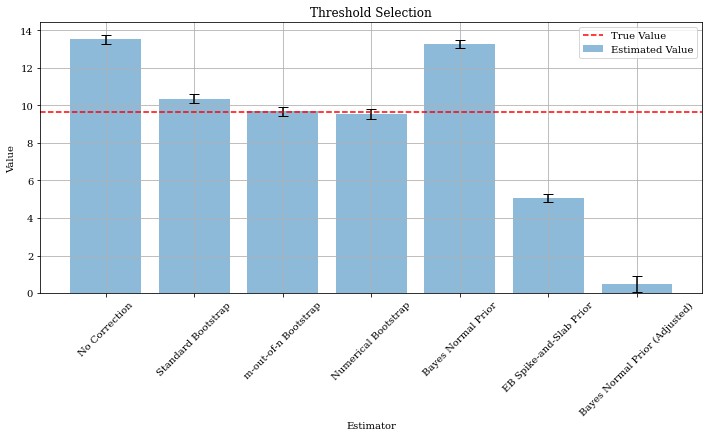

In [ ]:
for optimizer_key in optimization_params.keys():
    wc_dict = {}
    val_est_dict = {}

    val_true_avg = wc_measures_dict[f'{optimizer_key}_nc_val_true_avg']
    val_true_se = wc_measures_dict[f'{optimizer_key}_nc_val_true_se']

    for estimator_key in ['nc'] + list(estimators_dict.keys()):
        estimator_name = estimators_dict[estimator_key]['display_name'] if estimator_key != 'nc' else 'No Correction'

        wc_dict.update({
            estimator_name: {
                "Avg. Winners Curse": wc_measures_dict[f'{optimizer_key}_{estimator_key}_wc_avg'],
                "S.E. Winners Curse": wc_measures_dict[f'{optimizer_key}_{estimator_key}_wc_se'],
            }
        })
        val_est_dict.update({
            estimator_name: {
                "Avg. Estimated Value": wc_measures_dict[f'{optimizer_key}_{estimator_key}_val_est_avg'],
                "S.E. Estimated Value": wc_measures_dict[f'{optimizer_key}_{estimator_key}_val_est_se'],
            }
        })

    print(f'\nWinner\'s Curse of Selection with {optimization_params[optimizer_key]["display_name"]}:')
    for estimator_name in wc_dict.keys():
        print(f'  - {estimator_name}: {wc_dict[estimator_name]["Avg. Winners Curse"]:.4f} ({wc_dict[estimator_name]["S.E. Winners Curse"]:.4f})')

    # bar plot comparing the true value and estiamted value frome each estimator 
    fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

    bar_positions = np.arange(len(val_est_dict))
    bar_values = [val_est_dict[estimator_name]["Avg. Estimated Value"] for estimator_name in val_est_dict.keys()]
    bar_errors = [1.95 * val_est_dict[estimator_name]["S.E. Estimated Value"] for estimator_name in val_est_dict.keys()]

    ax.bar(bar_positions, bar_values, yerr=bar_errors, capsize=5, color='C0', alpha=0.5, label='Estimated Value')

    ax.axhline(y=val_true_avg, color='red', linestyle='--', label='True Value')

    ax.set_xlabel('Estimator')
    ax.set_ylabel('Value')
    ax.set_title(f'{optimization_params[optimizer_key]["display_name"]} Selection')
    ax.set_xticks(bar_positions, labels=val_est_dict.keys(), rotation=45)
    ax.legend()
    ax.grid()
    plt.tight_layout()
    plt.show()


# Comparative Statics

## Number of Arms

# Sketch

In [ ]:
dgp_params = {
    'n_experiments': 100, 
    'prior_mean': 0.1, 
    'prior_std': 0.1, 
    'noise_std': 1.0, 
    'prior_seed': 0,
}

data_params = {'sample_size': 100}

In [10]:
dgp = RCTs(**dgp_params)
treated_sample, control_sample = dgp.sample(sample_size=data_params['sample_size'], seed=0)

emp_te_arr, _, p_val_arr = rct.difference_in_means(treated_sample, control_sample)
sampling_vars = (treated_sample.var(0) + control_sample.var(0)) / data_params['sample_size']

threshold_selection = rct.select_above_threshold(treatment_effects=emp_te_arr, p_vals=p_val_arr, threshold=0.0)

In [23]:
eb_post_mean_arr = rct.empirical_bayes_spike_slab(
    mle_treatment_effects=emp_te_arr,
    sampling_vars=sampling_vars,
    pi=0.5, 
    max_iter=100, 
    tol=1e-6,
)

In [24]:
adj_eb_post_mean_arr = rct.empirical_bayes_spike_slab_selection_adjusted(
    mle_estimates=emp_te_arr, 
    selection=threshold_selection, 
    sample_vars=sampling_vars, 
    threshold=0.0, 
    pi=0.5, 
    max_iter=100, 
    tol=1e-6, 
    epsilon=1e-6
)

In [25]:
adj_bayes_post_mean_arr = rct.bayes_normal_selection_adjusted(
    mle_estimates=emp_te_arr, 
    selection=threshold_selection, 
    sample_vars=sampling_vars, 
    threshold=0.0, 
    prior_mean=0.0, 
    prior_std=1.0
)

In [27]:
compare = pd.DataFrame({
    'True Value': dgp.treatment_effects[threshold_selection],
    'Empirical Estimate': emp_te_arr[threshold_selection],
    'Adj. Bayes (Normal)': adj_bayes_post_mean_arr[threshold_selection],
    'Adj. EB (Spike & Slab)': adj_eb_post_mean_arr[threshold_selection]
})
compare.sum()

True Value                 7.967183
Empirical Estimate        11.269625
Adj. Bayes (Normal)       -2.162168
Adj. EB (Spike & Slab)     4.758662
dtype: float64

In [30]:
optimization_params = {
    'threshold': {
        'optimizer': rct.select_above_threshold,
        'params': {'threshold': 0.0},
        'display_name': 'Threshold'
    },
}

_, val_est_dict = empirical_bayes_selection_adjusted_estimate(
    treated_sample, control_sample, optimization_params, selection_threshold=0.0, pi=0.5, max_iter=100, tol=1e-6
)

{'threshold': 4.758661986956858}